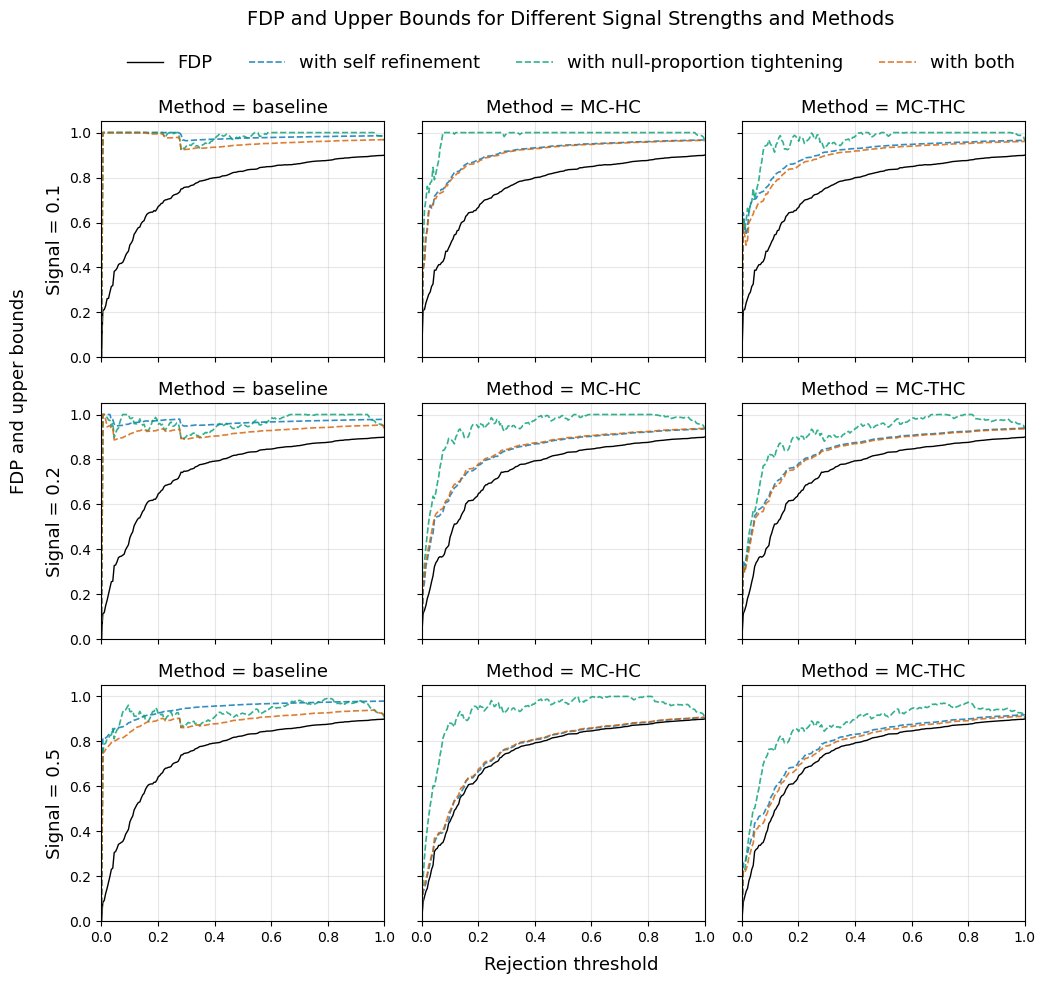

In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("experiment_result/FDP_outlier_fixed_purity.npz", allow_pickle=True)

grid = data["grid"]
signal_strengths = data["signal_strengths"]
methods = data["methods"]          # keep original, so keys match the dicts
method_to_plot = [methods[1], methods[0], methods[2]]   # column order

fdp_both = data["fdp_both"].item()
fdp_upper_boost1 = data["fdp_upper_boost1"].item()
fdp_upper_boost2 = data["fdp_upper_boost2"].item()
fdp_upper_both = data["fdp_upper_both"].item()

# Create subplot layout
fig, axes = plt.subplots(len(signal_strengths), len(methods),
                         figsize=(12, 10), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

legend_handles, legend_labels = None, None

for i, signal_strength in enumerate(signal_strengths):
    for j, method in enumerate(method_to_plot):

        key = (signal_strength, method)
        ax = axes[i, j]

        # FDP and bounds
        line_fdp, = ax.plot(
            grid, fdp_both[key],
            label='FDP',
            color='black', linewidth=1
        )
        line_boost1, = ax.plot(
            grid, fdp_upper_boost1[key],
            '--', color='#0072B2', linewidth=1.2, alpha=0.8,
            label='with self refinement'
        )
        line_boost2, = ax.plot(
            grid, fdp_upper_boost2[key],
            '--', color='#009E73', linewidth=1.2, alpha=0.8,
            label='with null-proportion tightening'
        )
        line_both, = ax.plot(
            grid, fdp_upper_both[key],
            '--', color='#D55E00', linewidth=1.2, alpha=0.8,
            label='with both'
        )

        # display name: rename KS -> baseline ONLY in title
        display_method = "baseline" if method == "KS" else method
        ax.set_title(f"Method = {display_method}", fontsize=13)

        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)

        if i == 0 and legend_handles is None:
            legend_handles = [line_fdp, line_boost1, line_boost2, line_both]
            legend_labels = [h.get_label() for h in legend_handles]

        if j == 0:
            ax.set_ylabel(f'Signal = {signal_strength}', fontsize=13)


# Shared axis labels
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', fontsize=13)
fig.text(0.04, 0.5, 'FDP and upper bounds', ha='center',
         rotation='vertical', fontsize=13)

fig.suptitle('FDP and Upper Bounds for Different Signal Strengths and Methods', fontsize=14)

fig.legend(
    legend_handles, legend_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=13,
    borderpad=0.3,
    bbox_to_anchor=(0.5, 0.95)
)

plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.94])

plt.savefig("all_figures/outlier_fixed_purity.pdf", format="pdf", dpi=300)
plt.show()


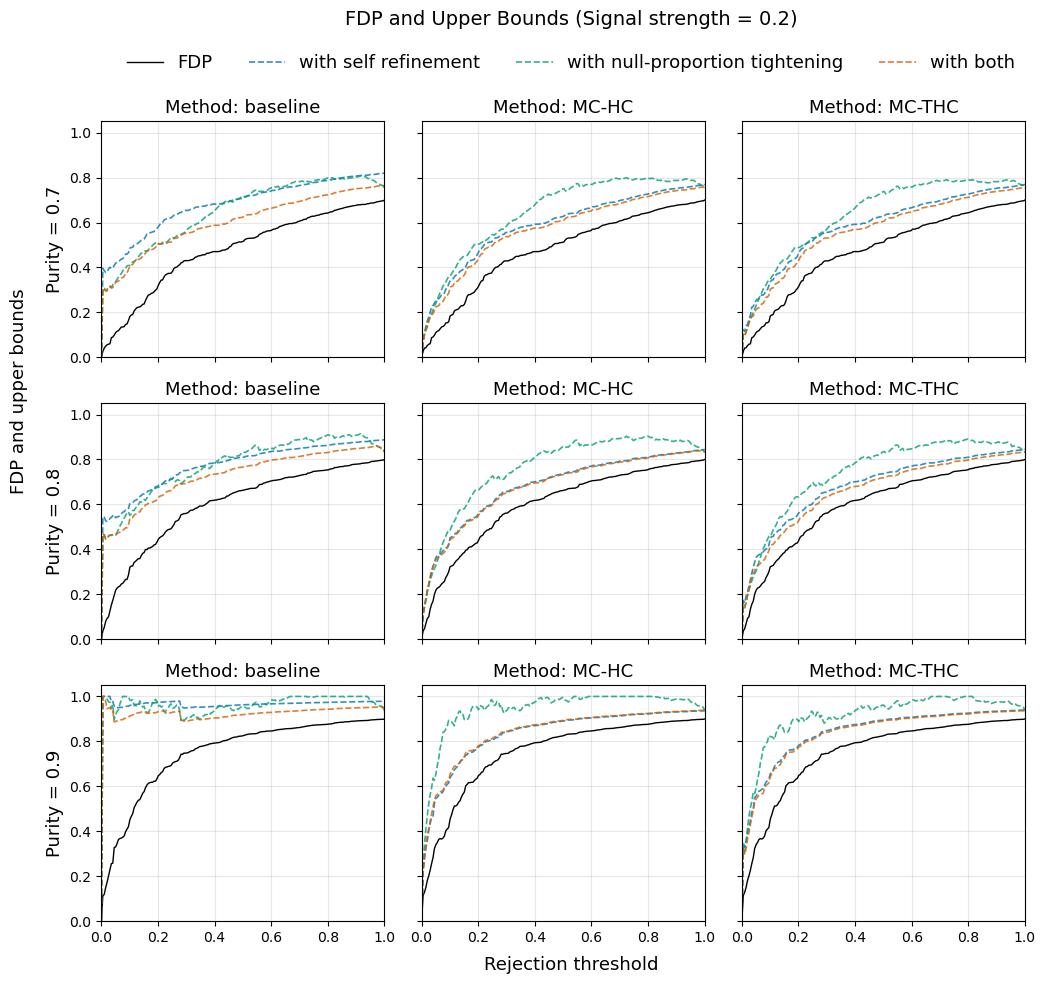

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Load saved results
data = np.load("experiment_result/FDP_outlier_fixed_signal_strength.npz",
               allow_pickle=True)

grid = data["grid"]
signal_strength = float(data["signal_strength"])
purities = data["purities"]

methods = data["methods"]            # keep original for keys
method_to_plot = [methods[1], methods[0], methods[2]]   # column order

# Display names (rename KS → baseline only when printing)
def display_name(m):
    return "baseline" if m == "KS" else m

fdp_boost1 = data["fdp_boost1"].item()
fdp_boost2 = data["fdp_boost2"].item()
fdp_both = data["fdp_both"].item()
fdp_upper_boost1 = data["fdp_upper_boost1"].item()
fdp_upper_boost2 = data["fdp_upper_boost2"].item()
fdp_upper_both = data["fdp_upper_both"].item()

# Create subplot layout
fig, axes = plt.subplots(len(signal_strengths), len(methods),
                         figsize=(12, 10), sharex=True, sharey=True)
axes = np.atleast_2d(axes)

legend_handles, legend_labels = None, None


for i, purity in enumerate(purities):
    for j, method in enumerate(method_to_plot):
        key = (purity, method)
        ax = axes[i, j]

        # FDP and 3 upper bounds
        line_fdp, = ax.plot(
            grid, fdp_both[key], color='black', linewidth=1, label='FDP'
        )
        line_boost1, = ax.plot(
            grid, fdp_upper_boost1[key],
            '--', color='#0072B2', linewidth=1.2, alpha=0.8,
            label='with self refinement'
        )
        line_boost2, = ax.plot(
            grid, fdp_upper_boost2[key],
            '--', color='#009E73', linewidth=1.2, alpha=0.8,
            label='with null-proportion tightening'
        )
        line_both, = ax.plot(
            grid, fdp_upper_both[key],
            '--', color='#D55E00', linewidth=1.2, alpha=0.8,
            label='with both'
        )

        # Display name (KS → baseline)
        ax.set_title(f"Method: {display_name(method)}", fontsize=13)

        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)

        if i == 0 and legend_handles is None:
            legend_handles = [line_fdp, line_boost1, line_boost2, line_both]
            legend_labels = [h.get_label() for h in legend_handles]

        if j == 0:
            ax.set_ylabel(f'Purity = {purity}', fontsize=13)

# Labels and title
fig.text(0.5, 0.02, 'Rejection threshold', ha='center', fontsize=13)
fig.text(0.04, 0.5, 'FDP and upper bounds', ha='center', rotation='vertical',
         fontsize=13)

fig.suptitle(f'FDP and Upper Bounds (Signal strength = {signal_strength})',
             fontsize=14)

# Top legend
fig.legend(
    legend_handles, legend_labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    fontsize=13,
    borderpad=0.3,
    bbox_to_anchor=(0.5, 0.95),
)

plt.tight_layout(rect=[0.05, 0.03, 0.9, 0.94])

# Save
plt.savefig("all_figures/outlier_fixed_signal_strength.pdf", format="pdf", dpi=300)

plt.show()


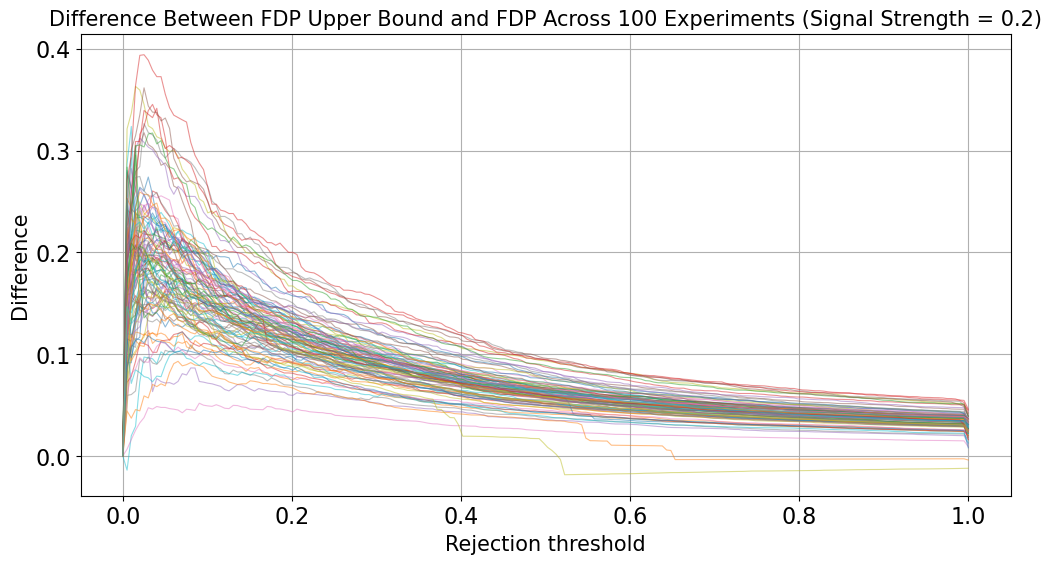

valid proportion (loaded): 0.97


In [17]:
# Load saved NPZ file
data = np.load(
    "experiment_result/FDP_multiple_runs_signal_0.2.npz",
    allow_pickle=True
)

grid = data["grid"]
fdp_list = data["fdp_list"]
fdp_upper_list = data["fdp_upper_list"]
diff_list = data["diff_list"]
reps = int(data["reps"])
valid_num = int(data["valid_num"])

# Replot
plt.figure(figsize=(12, 6))

for rep in range(reps):
    plt.plot(grid, diff_list[rep], alpha=0.5, linewidth=0.8)

plt.xlabel('Rejection threshold', fontsize = 15)
plt.ylabel('Difference', fontsize = 15)
plt.title('Difference Between FDP Upper Bound and FDP Across 100 Experiments (Signal Strength = 0.2)', fontsize = 15)
plt.grid(True)
plt.savefig('all_figures/outlier_multiple_0.2.pdf', format='pdf')
plt.show()

print('valid proportion (loaded):', valid_num / reps)